### [Time Series Forecasting with Transformer Models](https://medium.com/@kyle-t-jones/time-series-forecasting-with-transformer-models-in-python-c04d02261b29)

In [1]:
!pip install -qq requests

In [2]:
import requests
from pathlib import Path

def download_file(url: str, rel_path: str):
    """
    Download a file from a URL and save it to the specified output path.

    Args:
        url (str): The URL of the resource to download.
        rel_path (str): Local file path where the downloaded file will be saved.
    """
    # Resolve the full output path (relative to current working directory)
    output_path = Path.cwd() / rel_path

    # Ensure the parent directory exists
    output_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        with requests.get(url, stream=True) as response:
            response.raise_for_status()  # Raise an exception for HTTP errors
            with open(output_path, "wb") as file:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        file.write(chunk)
        print(f"Downloaded successfully to: {output_path}")

    except requests.exceptions.RequestException as e:
        print(f"Failed to download the file: {e}")


download_file(
    "https://www.eia.gov/state/seds/sep_use/total/csv/use_OK.csv",
    "data/use_OK.csv"
)

Downloaded successfully to: /content/data/use_OK.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dense, Input, Dropout
from tensorflow.keras.models import Model

np.random.seed(42)
tf.random.set_seed(42)

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

In [5]:
import sys
if 'google.colab' in sys.modules:
  BASE_DIR = Path.cwd()
else:
  BASE_DIR = Path(__file__).resolve().parents[1]

# Load Oklahoma energy consumption data (aggregate across all MSN codes)
data_path = BASE_DIR / "data" / "use_OK.csv"
df = pd.read_csv(data_path)

# Extract year columns (numeric columns) and aggregate over all MSN rows
year_cols = [col for col in df.columns if col.isdigit()]
year_totals = df[year_cols].apply(pd.to_numeric, errors="coerce").sum(axis=0)

# Build time series indexed by year
ts_data = pd.Series(
    data=year_totals.values,
    index=pd.to_datetime(year_totals.index, format="%Y"),
).sort_index()

print(f"Time series length: {len(ts_data)}")
print(f"Date range: {ts_data.index.min()} to {ts_data.index.max()}")
print(f"Value range: {ts_data.min():.2f} to {ts_data.max():.2f}")
print(f"\nFirst 10 values:\n{ts_data.head(10)}")

Time series length: 64
Date range: 1960-01-01 00:00:00 to 2023-01-01 00:00:00
Value range: 8717289.65 to 24779504.34

First 10 values:
1960-01-01    8.717290e+06
1961-01-01    8.750503e+06
1962-01-01    1.025223e+07
1963-01-01    1.135230e+07
1964-01-01    1.181251e+07
1965-01-01    1.145369e+07
1966-01-01    1.116997e+07
1967-01-01    1.145611e+07
1968-01-01    1.259215e+07
1969-01-01    1.328019e+07
dtype: float64


In [6]:
# Normalize for neural networks
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts_data.values.reshape(-1, 1)).flatten()

# Create sequences for time series forecasting
def create_sequences(data, seq_length, forecast_horizon=12):
    """
    Create input-output sequences for time series forecasting.

    Parameters:
    -----------
    data : array-like
        Time series data
    seq_length : int
        Number of past observations to use as input
    forecast_horizon : int
        Number of future periods to forecast

    Returns:
    --------
    X : ndarray
        Input sequences (n_samples, seq_length)
    y : ndarray
        Target sequences (n_samples, forecast_horizon)
    """
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon + 1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+forecast_horizon])
    return np.array(X), np.array(y)

# Configuration
seq_length = 20  # Use 20 years of history
forecast_horizon = 5  # Forecast 5 years ahead

# Create sequences
X, y = create_sequences(ts_scaled, seq_length, forecast_horizon)

# Split into train/test (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Sequence length: {seq_length}")
print(f"Forecast horizon: {forecast_horizon}")

Training samples: 32
Test samples: 8
Sequence length: 20
Forecast horizon: 5


In [7]:
# Use original (non-scaled) data for ARIMA
ts_train = ts_data[:split_idx + seq_length]
ts_test = ts_data[split_idx + seq_length:]

# Fit ARIMA model
# Order (p, d, q): p=autoregressive, d=differencing, q=moving average
print("Fitting ARIMA model...")
start_time = time.time()

arima_model = ARIMA(ts_train, order=(2, 1, 2))
arima_fitted = arima_model.fit()

arima_time = time.time() - start_time
print(f"ARIMA training time: {arima_time:.2f} seconds")

# Forecast
arima_forecast = arima_fitted.forecast(steps=min(len(ts_test), forecast_horizon))

# Evaluate on first forecast step for comparison
arima_mae = mean_absolute_error(ts_test[:len(arima_forecast)], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(ts_test[:len(arima_forecast)], arima_forecast))

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")

Fitting ARIMA model...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


ARIMA training time: 1.71 seconds
ARIMA MAE: 236037.19
ARIMA RMSE: 276797.35


In [8]:
# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(forecast_horizon)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

# Train with early stopping
print("Training LSTM model...")
start_time = time.time()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")

# Predict
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0)

# Evaluate (using first forecast step for comparison)
lstm_mae = mean_absolute_error(y_test[:, 0], lstm_pred[:, 0])
lstm_rmse = np.sqrt(mean_squared_error(y_test[:, 0], lstm_pred[:, 0]))

print(f"LSTM MAE: {lstm_mae:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,855 (120.53 KB)

 Trainable params: 30,855 (120.53 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM model...
LSTM training time: 9.15 seconds
LSTM MAE: 0.0681
LSTM RMSE: 0.0731


In [9]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Transformer encoder block with multi-head attention"""
    # Multi-head self-attention
    attention = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    attention = Dropout(dropout)(attention)
    attention = LayerNormalization(epsilon=1e-6)(inputs + attention)

    # Feed-forward network
    ffn = Dense(ff_dim, activation="relu")(attention)
    ffn = Dense(inputs.shape[-1])(ffn)
    ffn = Dropout(dropout)(ffn)
    outputs = LayerNormalization(epsilon=1e-6)(attention + ffn)
    return outputs

def build_transformer_model(seq_length, forecast_horizon, head_size=64,
                           num_heads=4, ff_dim=128, num_layers=2, dropout=0.2):
    """Build Transformer model for time series forecasting"""
    inputs = Input(shape=(seq_length, 1))
    x = inputs

    # Stack transformer encoder layers
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # Global average pooling to get fixed-size representation
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    outputs = Dense(forecast_horizon)(x)

    model = Model(inputs, outputs)
    return model

In [10]:
# Build and compile model
transformer_model = build_transformer_model(seq_length, forecast_horizon)
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
transformer_model.summary()

# Train
print("Training Transformer model...")
start_time = time.time()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history_trans = transformer_model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

transformer_time = time.time() - start_time
print(f"Transformer training time: {transformer_time:.2f} seconds")

# Predict
transformer_pred = transformer_model.predict(X_test_lstm, verbose=0)

# Evaluate
transformer_mae = mean_absolute_error(y_test[:, 0], transformer_pred[:, 0])
transformer_rmse = np.sqrt(mean_squared_error(y_test[:, 0], transformer_pred[:, 0]))

print(f"Transformer MAE: {transformer_mae:.4f}")
print(f"Transformer RMSE: {transformer_rmse:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 1)     │      1,793 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 20, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 1)     │          0 │ input_layer_1[0]… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 1)     │        129 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 1)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 1)     │      1,793 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 20, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 1)     │        129 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 20, 1)     │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 1)     │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,265 (20.57 KB)

 Trainable params: 5,265 (20.57 KB)

 Non-trainable params: 0 (0.00 B)

Training Transformer model...
Transformer training time: 21.91 seconds
Transformer MAE: 0.7471
Transformer RMSE: 0.7478


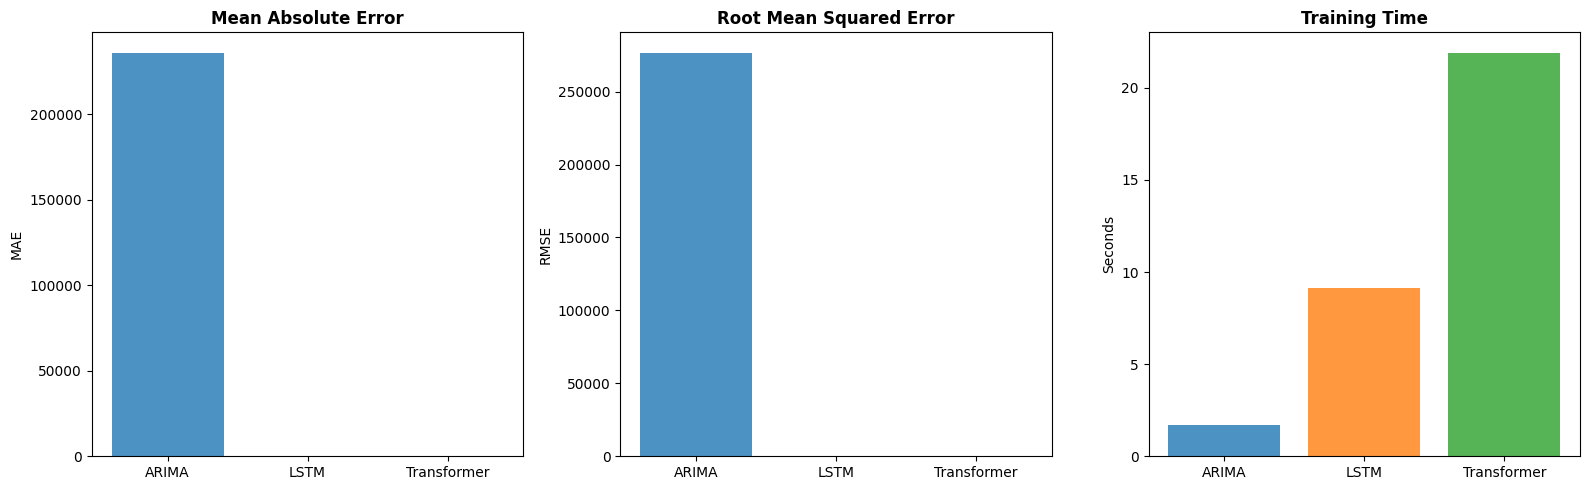


MODEL COMPARISON SUMMARY
Model           MAE          RMSE         Time (s)    
------------------------------------------------------------
ARIMA           236037.1936  276797.3499  1.71        
LSTM            0.0681       0.0731       9.15        
Transformer     0.7471       0.7478       21.91       


In [11]:
# Compile results
results = {
    'ARIMA': {
        'MAE': arima_mae,
        'RMSE': arima_rmse,
        'Time': arima_time
    },
    'LSTM': {
        'MAE': lstm_mae,
        'RMSE': lstm_rmse,
        'Time': lstm_time
    },
    'Transformer': {
        'MAE': transformer_mae,
        'RMSE': transformer_rmse,
        'Time': transformer_time
    }
}

# Create comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plt.rcParams.update({
    'axes.grid': False,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# MAE comparison
mae_values = [results[m]['MAE'] for m in results.keys()]
axes[0].bar(results.keys(), mae_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
axes[0].set_title('Mean Absolute Error', fontweight='bold', fontsize=12)
axes[0].set_ylabel('MAE')
# RMSE comparison
rmse_values = [results[m]['RMSE'] for m in results.keys()]
axes[1].bar(results.keys(), rmse_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
axes[1].set_title('Root Mean Squared Error', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RMSE')
# Training time comparison
time_values = [results[m]['Time'] for m in results.keys()]
axes[2].bar(results.keys(), time_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
axes[2].set_title('Training Time', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Seconds')
plt.tight_layout()
plt.savefig('transformer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<15} {'MAE':<12} {'RMSE':<12} {'Time (s)':<12}")
print("-"*60)
for model, metrics in results.items():
    print(f"{model:<15} {metrics['MAE']:<12.4f} {metrics['RMSE']:<12.4f} {metrics['Time']:<12.2f}")

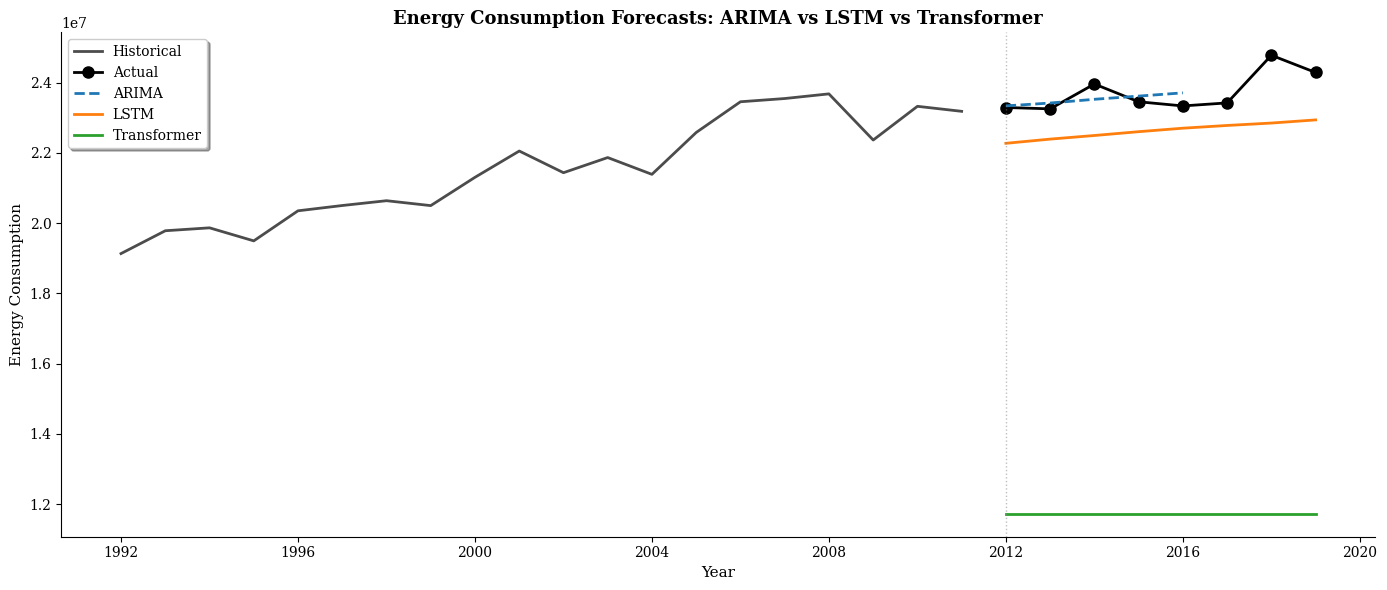

In [12]:
# Get test period dates
test_dates = ts_data.index[split_idx + seq_length:split_idx + seq_length + len(y_test)]

# Inverse transform predictions for visualization
lstm_pred_inv = scaler.inverse_transform(lstm_pred[:, 0].reshape(-1, 1)).flatten()
transformer_pred_inv = scaler.inverse_transform(transformer_pred[:, 0].reshape(-1, 1)).flatten()
y_test_inv = scaler.inverse_transform(y_test[:, 0].reshape(-1, 1)).flatten()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Plot historical data
historical_dates = ts_data.index[:split_idx + seq_length]
ax.plot(historical_dates[-20:], ts_data.values[split_idx + seq_length - 20:split_idx + seq_length],
        'k-', linewidth=2, label='Historical', alpha=0.7)

# Plot actual test values
ax.plot(test_dates[:len(y_test_inv)], y_test_inv,
        'o-', linewidth=2, markersize=8, label='Actual', color='black')

# Plot forecasts
ax.plot(test_dates[:len(arima_forecast)], arima_forecast,
        '--', linewidth=2, label='ARIMA', color='#1f77b4')
ax.plot(test_dates[:len(lstm_pred_inv)], lstm_pred_inv,
        '-', linewidth=2, label='LSTM', color='#ff7f0e')
ax.plot(test_dates[:len(transformer_pred_inv)], transformer_pred_inv,
        '-', linewidth=2, label='Transformer', color='#2ca02c')

# Add forecast boundary
ax.axvline(test_dates[0], color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Energy Consumption', fontsize=11)
ax.set_title('Energy Consumption Forecasts: ARIMA vs LSTM vs Transformer',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
if "google.colab" not in sys.modules:
  plt.savefig('forecast_comparison.png', dpi=300, bbox_inches='tight')
plt.show()